## Load JAX, KDExpress, and matplotlib for plotting

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", 'cpu') # put 'gpu' here if you have one
import jax.numpy as jnp

import os,sys
parent_dir = os.getcwd() + '/../src/'
sys.path.append(parent_dir)
from KDExpress import fft_kde1d, binned_kde1d, silverman_bw1d, build_hist_edges

import matplotlib.pyplot as plt

 ## Generate random weighted 1-D data 

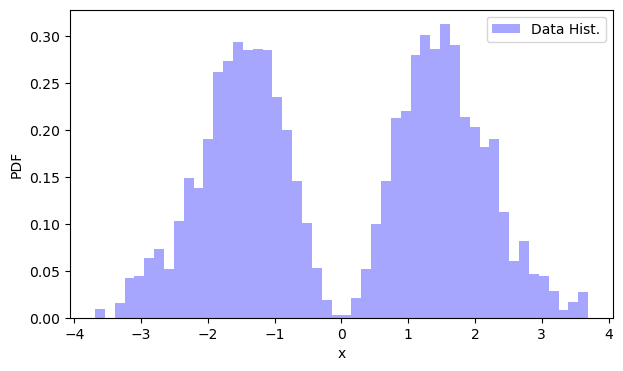

In [2]:
key = jax.random.PRNGKey(42)
data_1d = jax.random.normal(key, shape=(10_000,))
weights = data_1d**2

# Plot
plt.figure(figsize=(7, 4))
plt.hist(data_1d, weights=weights, bins=50, density=True, color='blue', alpha=0.35, label='Data Hist.')
plt.ylabel("PDF")
plt.xlabel("x")
plt.legend()
plt.show()

## Define the points where the PDF is evaluated and compute the bin edges around them. The corresponding histogram does not appear very smooth.

Bin edges shape =  (501,)


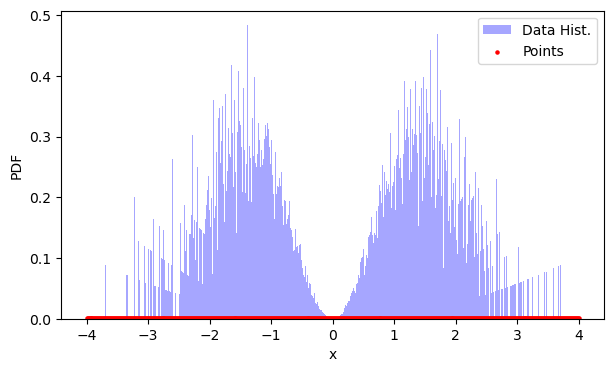

In [3]:
points = jnp.linspace(-4, 4, 500)
bin_edges = build_hist_edges(points)
print("Bin edges shape = ", bin_edges.shape)

# Plot
plt.figure(figsize=(7, 4))
plt.hist(data_1d, weights=weights, bins=bin_edges, density=True, color='blue', alpha=0.35, label='Data Hist.')
plt.scatter(points, jnp.zeros_like(points)+0.001, c='red', s=5 , label='Points')
plt.ylabel("PDF")
plt.xlabel("x")
plt.legend()
plt.show()

## The KDE is computed by convolving the previous "wavy" histogram with a Gaussian kernel. The convolution is (efficiently) performed using an FFT.

Estimated bandwidth =  0.14030946460170665


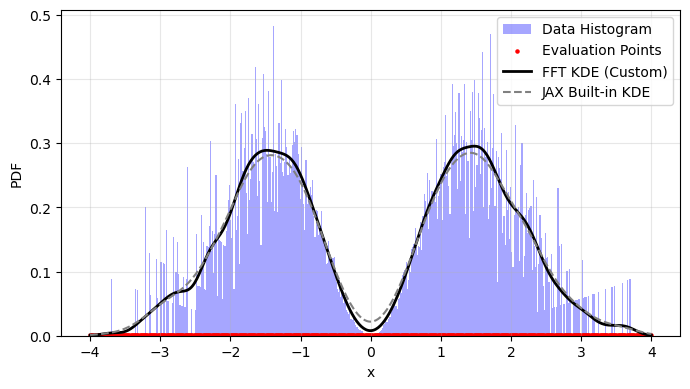

In [4]:
# Calculate optimal bandwidth using Silverman's rule (or use a user-defined value)
bw = silverman_bw1d(data_1d)  
print("Estimated bandwidth = ", bw)

# Compute KDE using FFT-based method (faster for large datasets)
# Note: We reuse bin_edges, though it's not strictly required. This may be useful when the grid is always the same.
pdf_est_fft = fft_kde1d(
    points, 
    data_1d, 
    weights=weights, 
    bin_edges=bin_edges, 
    bw=bw
)

# Compute KDE using JAX's built-in gaussian_kde implementation
pdf_est_jax = jax.scipy.stats.gaussian_kde(
  data_1d, 
  weights=weights, 
  bw_method=bw
)(points)

# Plot
plt.figure(figsize=(7, 4))
plt.hist(
  data_1d, 
  weights=weights, 
  bins=bin_edges, 
  density=True, 
  color='blue', 
  alpha=0.35, 
  label='Data Histogram'
)
plt.scatter(
  points, 
  jnp.zeros_like(points)+0.001,  # Small vertical offset for visibility
  c='red', 
  s=5, 
  label='Evaluation Points'
)
plt.plot(
  points, 
  pdf_est_fft, 
  c='black', 
  linewidth=2,
  label='FFT KDE (Custom)'
)
plt.plot(
  points, 
  pdf_est_jax, 
  c='gray', 
  linestyle='--',
  label='JAX Built-in KDE'
)

plt.ylabel("PDF")
plt.xlabel("x")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Alternatively, we can use the binned KDE. 

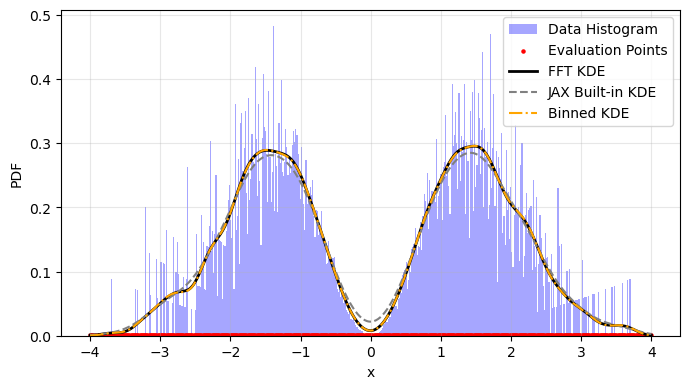

In [5]:
pdf_est_binned = binned_kde1d(points, 
  data_1d, 
  weights=weights, 
  bw = bw, 
  nbins=200 # parameter to tune
)

# Plot
plt.figure(figsize=(7, 4))
plt.hist(
  data_1d, 
  weights=weights, 
  bins=bin_edges, 
  density=True, 
  color='blue', 
  alpha=0.35, 
  label='Data Histogram'
)
plt.scatter(
  points, 
  jnp.zeros_like(points)+0.001,  # Small vertical offset for visibility
  c='red', 
  s=5, 
  label='Evaluation Points'
)
plt.plot(
  points, 
  pdf_est_fft, 
  c='black', 
  linewidth=2,
  label='FFT KDE'
)
plt.plot(
  points, 
  pdf_est_jax, 
  c='gray', 
  linestyle='--',
  label='JAX Built-in KDE'
)
plt.plot(points, 
  pdf_est_binned, 
  c='orange', 
  ls='-.', 
  label='Binned KDE'
)

plt.ylabel("PDF")
plt.xlabel("x")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## The binned KDE can also truncate points outside cut_sigma_points standard deviations from the data support. This speeds up KDE evaluation when the evaluation points range is much larger than the dataset's one. In such cases, the FFT-based KDE remains efficient due to its inherent histogram-based computation.

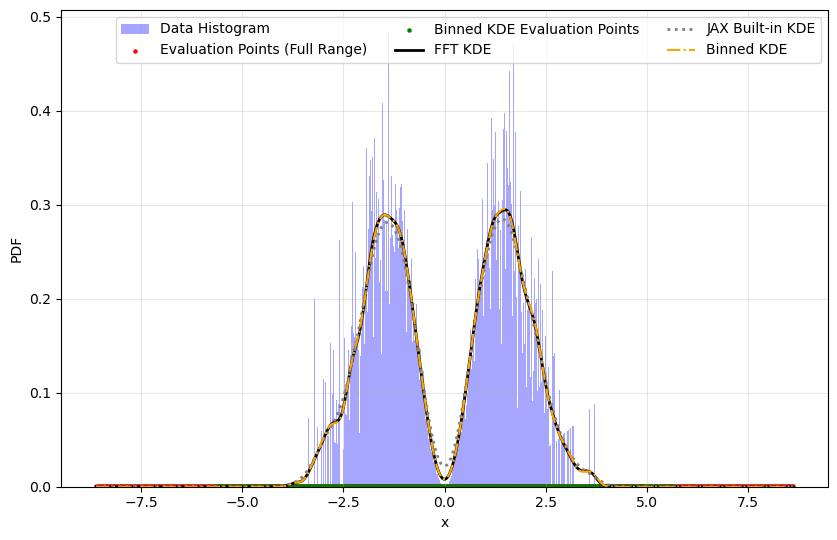

In [6]:
# Create evaluation points extending 5 standard deviations beyond data range
min_data = jnp.min(data_1d)
max_data = jnp.max(data_1d)
std_data = jnp.std(data_1d)

large_support_points = jnp.linspace(
  min_data - 5*std_data, 
  max_data + 5*std_data, 
  500
)

# Create effective points for binned KDE evaluation (2 sigma range) only for visualization.
# This is the same "effective grid" that is created within binned_kde1d.
# Outisde this "effective grid" binned_kde1d is zero.
# These are the actual points where binned KDE is computed before interpolation
cut_sigma_data = 2
eff_points = jnp.linspace(
  min_data - cut_sigma_data*std_data,
  max_data + cut_sigma_data*std_data,
  len(large_support_points)//2  
)

# Compute KDE using different methods:
# 1. Binned KDE 
pdf_est_binned_2 = binned_kde1d(
  large_support_points, 
  data_1d, 
  weights=weights, 
  bw=bw,
  nbins=200,  
  cut_sigma_data=2  
)

# 2. FFT-based KDE
pdf_est_fft_2 = fft_kde1d(
  large_support_points, 
  data_1d, 
  weights=weights, 
  bw=bw
)

# 3. JAX's built-in Gaussian KDE
pdf_est_jax_2 = jax.scipy.stats.gaussian_kde(
    data_1d, 
    weights=weights, 
    bw_method=bw
)(large_support_points)

# Plot
plt.figure(figsize=(8.5, 5.5))
plt.hist(
  data_1d, 
  weights=weights, 
  bins=bin_edges, 
  density=True, 
  color='blue', 
  alpha=0.35, 
  label='Data Histogram'
)
plt.scatter(
  large_support_points, 
  jnp.zeros_like(large_support_points) + 0.001,  # Small offset for visibility
  c='red', 
  s=5, 
  label='Evaluation Points (Full Range)'
)
plt.scatter(
  eff_points, 
  jnp.zeros_like(eff_points) + 0.001,
  c='green', 
  s=5, 
  label='Binned KDE Evaluation Points'
)
plt.plot(
  large_support_points, 
  pdf_est_fft_2, 
  c='black', 
  linewidth=2,
  label='FFT KDE'
)
plt.plot(
  large_support_points, 
  pdf_est_jax_2, 
  c='gray', 
  linestyle=':', 
  linewidth=2,
  label='JAX Built-in KDE'
)
plt.plot(
  large_support_points, 
  pdf_est_binned_2, 
  c='orange', 
  linestyle='-.',
  label='Binned KDE'
)
plt.ylabel("PDF")
plt.xlabel("x")
plt.legend(ncols=3)  
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()